# Article Deduplication Analysis for Sustainability Scorecard

## Project Context

This notebook analyzes and optimizes the article deduplication logic used in the **Sportswear Sustainability Scorecard**. The scorecard ranks brands based on ESG news sentiment, and similar news stories from different sources need to be deduplicated to ensure fair scoring.

**Current Implementation** (`scripts/export_website_feed.py`):
- **Embedding**: `all-MiniLM-L6-v2` (384-dim) via `NoveltyScorer`
- **Algorithm**: Greedy cosine similarity clustering
- **Threshold**: 0.75 (recently lowered from 0.85)

---

## Notebook Objective

Develop an empirically-justified deduplication configuration by:

1. **Analyzing the baseline** approach and understanding threshold sensitivity
2. **Creating a labeled validation set** for precision/recall evaluation
3. **Comparing embedding methods**: sentence-transformers vs TF-IDF+LSA
4. **Comparing clustering algorithms**: greedy vs HDBSCAN vs agglomerative
5. **Tuning hyperparameters** for optimal F1 on labeled pairs
6. **Validating scorecard stability** across configurations

---

## Why Deduplication Matters

| Without Deduplication | With Deduplication |
|----------------------|--------------------|
| Popular news stories appear from 5-10 sources | Each story counted once |
| Brands mentioned in viral news get inflated scores | Fair scoring across brands |
| Scorecard volatile to news cycles | More stable brand rankings |

---

## Contents

1. [Setup](#1-setup)
2. [Data Loading](#2-data-loading)
3. [Baseline Analysis](#3-baseline-analysis)
4. [Evaluation Framework](#4-evaluation-framework)
5. [Embedding Comparison](#5-embedding-comparison)
6. [Dimensionality Reduction](#6-dimensionality-reduction)
7. [Clustering Algorithms](#7-clustering-algorithms)
8. [Hyperparameter Tuning](#8-hyperparameter-tuning)
9. [Recommendations](#9-recommendations)
10. [Summary](#10-summary)

## 1. Setup

In [1]:
# Standard imports
import json
import sys
import warnings
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'scripts'))

# Project imports - deduplication utilities
from src.dedup1_nb.data_utils import (
    load_articles_from_db,
    prepare_text_representations,
    load_validation_pairs,
    save_validation_pairs,
)
from src.dedup1_nb.embedders import (
    SentenceTransformerEmbedder,
    TfidfLsaEmbedder,
    get_embedder,
)
from src.dedup1_nb.clustering import (
    greedy_cosine_clustering,
    hdbscan_clustering,
    agglomerative_clustering,
    kmeans_clustering,
    get_clustering_method,
)
from src.dedup1_nb.evaluation import (
    calculate_cluster_metrics,
    evaluate_on_labeled_pairs,
    compute_scorecard_stability,
    create_validation_pairs,
    threshold_sweep,
    split_validation_pairs,
    find_optimal_threshold_with_recall_constraint,
)
from src.dedup1_nb.visualization import (
    plot_threshold_analysis,
    plot_embedding_space,
    plot_cluster_sizes,
    plot_method_comparison,
    plot_similarity_distribution,
)

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')

# Configuration
RANDOM_STATE = 42
CURRENT_THRESHOLD = 0.72  # Current production threshold
SCORECARD_PERIOD_DAYS = 30  # Days to load for analysis
MIN_RECALL_TARGET = 0.98  # Minimum recall for fair brand scoring
HOLDOUT_FRACTION = 0.3  # Fraction of labeled pairs for holdout

# Paths
DATA_DIR = project_root / 'data'
MODELS_DIR = project_root / 'models'
IMAGES_DIR = project_root / 'images'

# Create directories
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

np.random.seed(RANDOM_STATE)

print("Setup complete!")
print(f"\nOptimization target: Maximize precision with recall >= {MIN_RECALL_TARGET}")
print(f"Holdout set fraction: {HOLDOUT_FRACTION*100:.0f}%")

Setup complete!

Optimization target: Maximize precision with recall >= 0.98
Holdout set fraction: 30%


## 2. Data Loading

Load recent labeled articles from the database for deduplication analysis.

In [2]:
# Load recent labeled articles
df = load_articles_from_db(
    days=SCORECARD_PERIOD_DAYS,
    labeling_status=['labeled'],
    min_content_length=100,
    verbose=True
)

Loaded 128 articles from last 30 days
  Labeling statuses: ['labeled']
  Date range: 2026-01-09 06:45:00 to 2026-02-07 16:42:12
  Sources: 109 unique


In [3]:
# Preview the data
print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head(3)


Dataset shape: (128, 11)

Columns: ['id', 'article_id', 'title', 'full_content', 'description', 'url', 'source_name', 'published_at', 'labeled_at', 'labeling_status', 'brands_mentioned']


,id,article_id,title,full_content,description,url,source_name,published_at,labeled_at,labeling_status,brands_mentioned
0,c4042ed0-eaa6-4f96-97f0-7473d41709d8,446387d1c210f2833ec997733e8eb7a7,These $160 Columbia jackets are now $39.98 at Academy Sports and it’s just the beginning of thei...,"This week Academy Sports + Outdoors quietly bumped their clearance from 50% to up to 70% off, an...","Major brands including Nike, Columbia, and Adidas now available at up to 70% off in Academy's ex...",https://www.pennlive.com/shopping-deals/2026/02/these-160-columbia-jackets-are-now-3998-at-acade...,Pennlive,2026-02-07 16:42:12,2026-02-08 14:31:08.786989+00:00,labeled,"[Nike, Adidas]"
1,1a15a652-ca53-425d-9360-83c0cd882c58,45d6fde0839d047f17f49a7872b96850,Under Armour Q3 Earnings Call Highlights,Get alerts:\n\nUnder Armour (NYSE:UA) executives told investors the company is moving into what ...,Under Armour (NYSE:UA) executives told investors the company is moving into what management desc...,https://www.americanbankingnews.com/2026/02/07/under-armour-q3-earnings-call-highlights.html,Americanbankingnews,2026-02-07 07:38:47,2026-02-08 14:30:29.162893+00:00,labeled,[Under Armour]
2,38cdd1e2-c18d-4088-b82f-c0d7b0f20e11,9407e32dfbdcce82a342cf2d056a3299,Feds Investigate Nike for Racial Discrimination,"When it comes to racism, Nike decided to “just do it.”\n\nThe woke footwear company that enthusi...",None,https://pjmedia.com/catherinesalgado/2026/02/06/feds-investigate-nike-for-racial-discrimination-...,pjmedia.com,2026-02-07 07:30:00,2026-02-07 14:31:03.584554+00:00,labeled,[Nike]


In [4]:
# Source distribution
print("\nTop 10 sources:")
print(df['source_name'].value_counts().head(10))


Top 10 sources:
source_name
finance.yahoo.com           6
webwire.com                 4
wwd.com                     4
nypost.com                  3
zerohedge.com               2
marketscreener.com          2
South China Morning Post    2
hngn.com                    2
oregonlive.com              2
textileworld.com            2
Name: count, dtype: int64


In [5]:
# Prepare text representations for embedding
# Using title + first 1000 chars of content (same as production)
texts = prepare_text_representations(
    df,
    text_col='full_content',
    title_col='title',
    max_content_chars=1000,
    include_title=True
)

print(f"Prepared {len(texts)} text representations")
print(f"\nSample text (first 200 chars):\n{texts[0][:200]}...")

Prepared 128 text representations

Sample text (first 200 chars):
These $160 Columbia jackets are now $39.98 at Academy Sports and it’s just the beginning of their massive clearance This week Academy Sports + Outdoors quietly bumped their clearance from 50% to up to...


## 3. Baseline Analysis

Analyze the current production deduplication approach (greedy cosine clustering with threshold 0.75).

In [6]:
# Create baseline embedder (same as production)
baseline_embedder = SentenceTransformerEmbedder(
    model_name='all-MiniLM-L6-v2',
    normalize=True
)

# Compute embeddings
print("Computing baseline embeddings...")
baseline_embeddings = baseline_embedder.fit_transform(texts)
print(f"Embedding shape: {baseline_embeddings.shape}")

Computing baseline embeddings...


Embedding shape: (128, 384)


Figure saved to /home/fdpearce/Documents/Courses/DataTalksClub/projects/machine-learning-zoomcamp/sportswear-esg-news-classifier/images/dedup_similarity_distribution.png


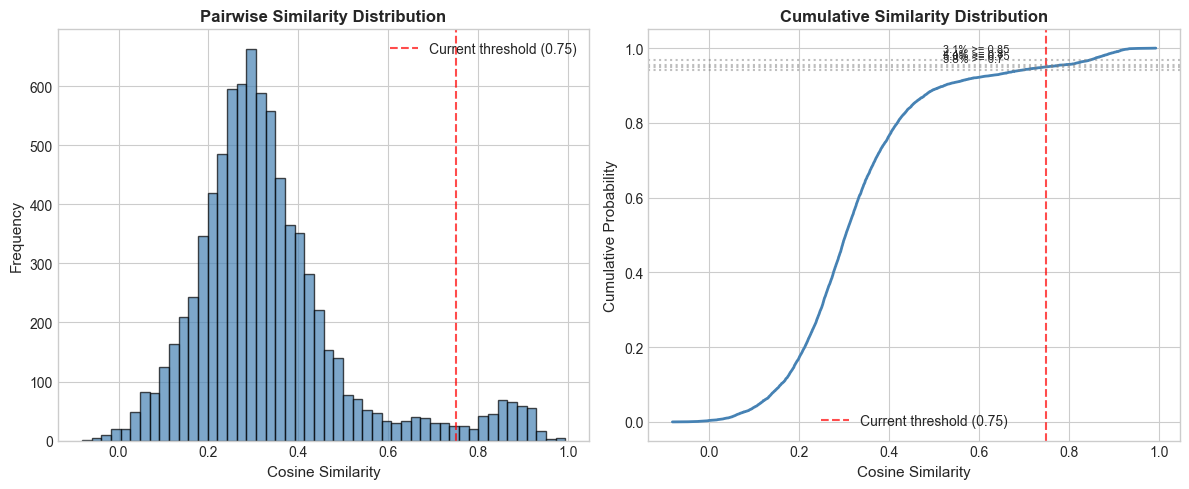


Similarity Statistics:
  Mean: 0.3338
  Std:  0.1730
  Min:  -0.0816
  Max:  0.9937
  Pairs >= 0.75: 408 (5.02%)
  Pairs >= 0.80: 356 (4.38%)


In [7]:
# Analyze similarity distribution
plot_similarity_distribution(
    baseline_embeddings,
    figsize=(12, 5),
    save_path=IMAGES_DIR / 'dedup_similarity_distribution.png'
)

In [8]:
# Run baseline deduplication (current production)
baseline_keep, baseline_meta = greedy_cosine_clustering(
    baseline_embeddings,
    threshold=CURRENT_THRESHOLD
)

print("\n" + "=" * 50)
print("BASELINE DEDUPLICATION RESULTS")
print("=" * 50)
print(f"\nArticles input: {len(df)}")
print(f"Articles kept:  {len(baseline_keep)}")
print(f"Duplicates removed: {baseline_meta['duplicates_removed']}")
print(f"Reduction rate: {baseline_meta['duplicates_removed'] / len(df) * 100:.1f}%")
print(f"\nNumber of clusters: {baseline_meta['n_clusters']}")


BASELINE DEDUPLICATION RESULTS

Articles input: 128
Articles kept:  59
Duplicates removed: 69
Reduction rate: 53.9%

Number of clusters: 59


In [9]:
# Calculate cluster quality metrics
baseline_cluster_metrics = calculate_cluster_metrics(
    baseline_embeddings,
    baseline_meta['cluster_labels']
)

print("\nCluster Quality Metrics:")
print(f"  Silhouette Score: {baseline_cluster_metrics['silhouette_score']:.4f}" if baseline_cluster_metrics['silhouette_score'] else "  Silhouette Score: N/A")
print(f"  Mean cluster size: {baseline_cluster_metrics['mean_cluster_size']:.2f}" if baseline_cluster_metrics['mean_cluster_size'] else "  Mean cluster size: N/A")
print(f"  Max cluster size: {baseline_cluster_metrics['max_cluster_size']}")
print(f"  Singleton clusters: {baseline_cluster_metrics['singleton_clusters']} ({baseline_cluster_metrics['singleton_ratio']*100:.1f}%)")


Cluster Quality Metrics:
  Silhouette Score: 0.1976
  Mean cluster size: 2.17
  Max cluster size: 24
  Singleton clusters: 43 (72.9%)


Figure saved to /home/fdpearce/Documents/Courses/DataTalksClub/projects/machine-learning-zoomcamp/sportswear-esg-news-classifier/images/dedup_baseline_cluster_sizes.png


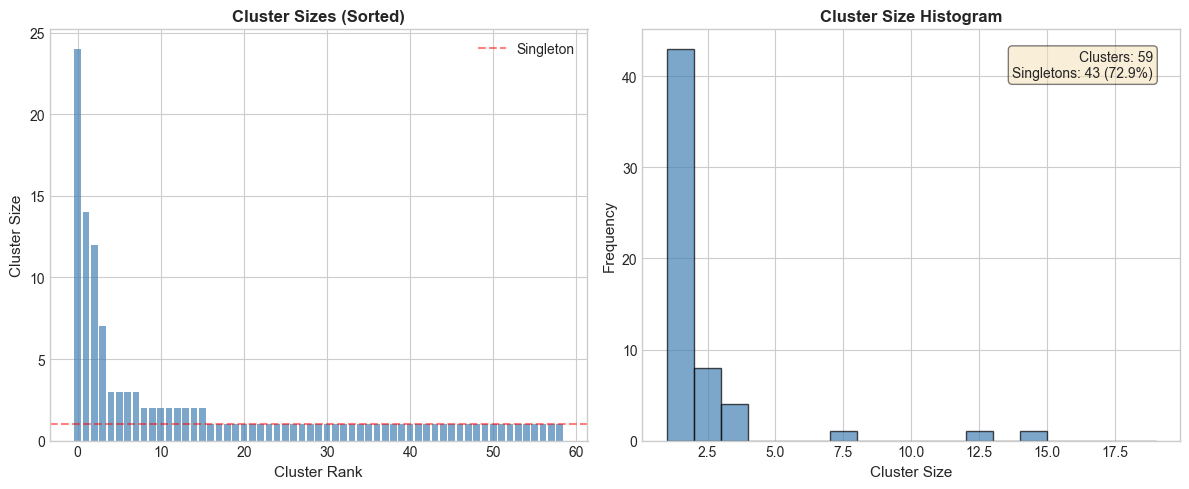

In [10]:
# Plot cluster sizes
plot_cluster_sizes(
    baseline_meta['cluster_labels'],
    figsize=(12, 5),
    save_path=IMAGES_DIR / 'dedup_baseline_cluster_sizes.png'
)

In [11]:
# Threshold sensitivity analysis
print("\nRunning threshold sweep...")
sweep_results = threshold_sweep(
    baseline_embeddings,
    thresholds=[0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
)

sweep_df = pd.DataFrame(sweep_results)
print("\nThreshold Sweep Results:")
print(sweep_df[['threshold', 'n_kept', 'n_removed', 'reduction_rate', 'n_clusters']].to_string(index=False))


Running threshold sweep...



Threshold Sweep Results:
 threshold  n_kept  n_removed  reduction_rate  n_clusters
      0.50      33         95        0.742188          33
      0.55      39         89        0.695312          39
      0.60      46         82        0.640625          46
      0.65      50         78        0.609375          50
      0.70      56         72        0.562500          56
      0.75      62         66        0.515625          62
      0.80      72         56        0.437500          72
      0.85      83         45        0.351562          83
      0.90     100         28        0.218750         100
      0.95     122          6        0.046875         122


Figure saved to /home/fdpearce/Documents/Courses/DataTalksClub/projects/machine-learning-zoomcamp/sportswear-esg-news-classifier/images/dedup_threshold_analysis.png


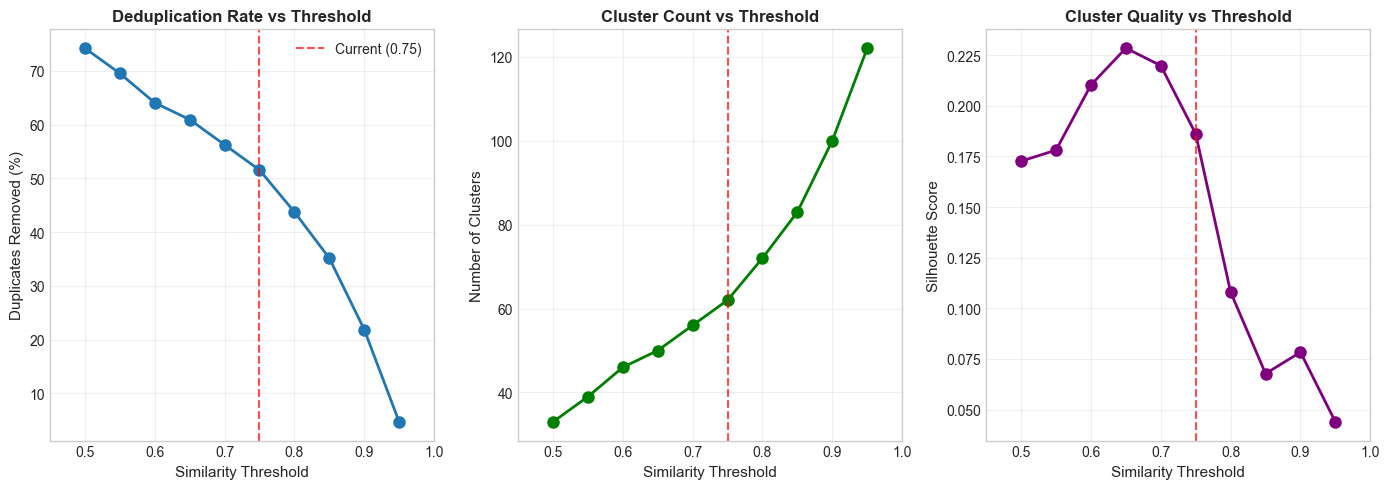

In [12]:
# Plot threshold analysis
plot_threshold_analysis(
    sweep_results,
    figsize=(14, 5),
    save_path=IMAGES_DIR / 'dedup_threshold_analysis.png'
)

In [13]:
# Examine sample duplicates at current threshold
print("\n" + "=" * 60)
print("SAMPLE DUPLICATE GROUPS (threshold = 0.75)")
print("=" * 60)

labels = np.array(baseline_meta['cluster_labels'])
cluster_sizes = {}
for label in set(labels):
    if label >= 0:
        size = sum(1 for l in labels if l == label)
        if size > 1:
            cluster_sizes[label] = size

# Show top 5 duplicate groups
sorted_clusters = sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True)[:5]

for cluster_id, size in sorted_clusters:
    print(f"\n--- Cluster {cluster_id} ({size} articles) ---")
    cluster_indices = [i for i, l in enumerate(labels) if l == cluster_id]
    for idx in cluster_indices[:3]:  # Show first 3
        print(f"  [{df.iloc[idx]['source_name']}] {df.iloc[idx]['title'][:80]}...")


SAMPLE DUPLICATE GROUPS (threshold = 0.75)

--- Cluster 2 (24 articles) ---
  [pjmedia.com] Feds Investigate Nike for Racial Discrimination...
  [oann.com] The Equal Employment Opportunity launches probe into Nike for alleged discrimina...
  [wwd.com] Nike EEOC Probe Reflects How Trump Administration Challenges DEI...

--- Cluster 4 (14 articles) ---
  [firstpost.com] Nike and Adidas face a new rival as China Anta takes stake in Puma – Firstpost...
  [Business Standard] From icon to also-ran: Puma's long slide as rivals Adidas and Anta loom...
  [Tekedia] Anta’s 29% Puma Stake Sparks Market Rally, as First Abu Dhabi Bank Records 22% P...

--- Cluster 10 (12 articles) ---
  [outdoorhub.com] Eddie Bauer Store Closures Likely as Retail Operator Prepares Bankruptcy Filing...
  [obj.ca] Eddie Bauer stores in Ottawa could close as company reportedly files for bankrup...
  [nypost.com] Eddie Bauer may close North America stores as Catalyst Brands eyes bankruptcy...

--- Cluster 35 (7 article

## 4. Evaluation Framework

Create a labeled validation set and split into tuning/holdout sets.

**Why split?** Using the same data for threshold tuning and evaluation biases metrics.
- **Tuning set (70%)**: Used to select best threshold/method
- **Holdout set (30%)**: Used for final unbiased evaluation

**Optimization goal**: Maximize precision while maintaining recall >= 98%
- High recall ensures we catch most duplicates (fair brand scoring)
- High precision avoids removing unique articles (data completeness)

In [14]:
# Check if validation pairs already exist
validation_pairs_path = DATA_DIR / 'dedup_validation_pairs.jsonl'

if validation_pairs_path.exists():
    print(f"Loading existing validation pairs from {validation_pairs_path}")
    validation_pairs = load_validation_pairs(str(validation_pairs_path))
    labeled_count = sum(1 for p in validation_pairs if p.get('is_duplicate') is not None)
    print(f"Loaded {len(validation_pairs)} pairs ({labeled_count} labeled)")
else:
    print("Creating new validation pairs for manual labeling...")
    validation_pairs = create_validation_pairs(
        baseline_embeddings,
        df,
        similarity_ranges=[
            (0.50, 0.60),
            (0.60, 0.70),
            (0.70, 0.75),
            (0.75, 0.80),
            (0.80, 0.85),
            (0.85, 0.90),
            (0.90, 0.95),
        ],
        n_pairs_per_range=10,
        random_state=RANDOM_STATE
    )
    
    # Save for manual labeling
    save_validation_pairs(validation_pairs, str(validation_pairs_path))
    print(f"\nCreated {len(validation_pairs)} pairs for manual labeling")
    print(f"Saved to: {validation_pairs_path}")
    print("\n*** ACTION REQUIRED: Manually label is_duplicate field in the file ***")

Loading existing validation pairs from /home/fdpearce/Documents/Courses/DataTalksClub/projects/machine-learning-zoomcamp/sportswear-esg-news-classifier/data/dedup_validation_pairs.jsonl
Loaded 120 pairs (120 labeled)


In [15]:
# Show sample pairs for labeling
print("\nSample pairs by similarity range:")
for sim_range in ['0.70-0.75', '0.75-0.80', '0.80-0.85']:
    range_pairs = [p for p in validation_pairs if p['similarity_range'] == sim_range][:2]
    print(f"\n--- {sim_range} ---")
    for p in range_pairs:
        print(f"  Similarity: {p['similarity']:.3f}")
        print(f"  1: [{p['source_1']}] {p['title_1'][:60]}...")
        print(f"  2: [{p['source_2']}] {p['title_2'][:60]}...")
        print(f"  is_duplicate: {p['is_duplicate']}")
        print()


Sample pairs by similarity range:

--- 0.70-0.75 ---
  Similarity: 0.708
  1: [newsone.com] EEOC Investigates Nike Over Anti - White Discrimination Clai...
  2: [businessoffashion.com] Nike Faces Federal Probe Over Alleged Discrimination Against...
  is_duplicate: True

  Similarity: 0.717
  1: [Kathmandupost] Puma’s long slide: the rise and fall of a German sports icon...
  2: [webwire.com] Statement by PUMA CEO Arthur Hoeld regarding the recent anno...
  is_duplicate: True


--- 0.75-0.80 ---
  Similarity: 0.772
  1: [ktvu.com] Eddie Bauer expected to close all stores in North America as...
  2: [midnorthmonitor.com] Eddie Bauer to close North American stores | Mid - North Mon...
  is_duplicate: True

  Similarity: 0.772
  1: [obj.ca] Eddie Bauer stores in Ottawa could close as company reported...
  2: [ktvu.com] Eddie Bauer expected to close all stores in North America as...
  is_duplicate: True


--- 0.80-0.85 ---
  Similarity: 0.847
  1: [City A.m.] ANTA Sports to Acquire 29% Sta

In [16]:
# Split labeled pairs into tuning and holdout sets
labeled_pairs = [p for p in validation_pairs if p.get('is_duplicate') is not None]

if labeled_pairs:
    # Split into tuning/holdout (stratified by label)
    tuning_pairs, holdout_pairs = split_validation_pairs(
        labeled_pairs,
        test_size=HOLDOUT_FRACTION,
        random_state=RANDOM_STATE,
        stratify_by_label=True
    )
    
    print("\n" + "=" * 50)
    print("TUNING/HOLDOUT SPLIT")
    print("=" * 50)
    print(f"\nTotal labeled pairs: {len(labeled_pairs)}")
    print(f"  - Duplicates: {sum(1 for p in labeled_pairs if p['is_duplicate'])}")
    print(f"  - Non-duplicates: {sum(1 for p in labeled_pairs if not p['is_duplicate'])}")
    
    print(f"\nTuning set: {len(tuning_pairs)} pairs")
    print(f"  - Duplicates: {sum(1 for p in tuning_pairs if p['is_duplicate'])}")
    print(f"  - Non-duplicates: {sum(1 for p in tuning_pairs if not p['is_duplicate'])}")
    
    print(f"\nHoldout set: {len(holdout_pairs)} pairs (for final evaluation)")
    print(f"  - Duplicates: {sum(1 for p in holdout_pairs if p['is_duplicate'])}")
    print(f"  - Non-duplicates: {sum(1 for p in holdout_pairs if not p['is_duplicate'])}")
    
    # Evaluate baseline on TUNING set (for comparison)
    article_ids = df['article_id'].astype(str).tolist()
    baseline_eval_tuning = evaluate_on_labeled_pairs(
        baseline_embeddings,
        article_ids,
        tuning_pairs,
        baseline_meta['cluster_labels']
    )
    
    print("\n" + "=" * 50)
    print(f"BASELINE EVALUATION ON TUNING SET (threshold={CURRENT_THRESHOLD})")
    print("=" * 50)
    print(f"\nPrecision: {baseline_eval_tuning['precision']:.3f}")
    print(f"Recall:    {baseline_eval_tuning['recall']:.3f}")
    print(f"F1 Score:  {baseline_eval_tuning['f1']:.3f}")
    print(f"\nConfusion Matrix:")
    print(f"  TP: {baseline_eval_tuning['true_positives']}  FP: {baseline_eval_tuning['false_positives']}")
    print(f"  FN: {baseline_eval_tuning['false_negatives']}  TN: {baseline_eval_tuning['true_negatives']}")
else:
    print("\nNo labeled pairs available yet.")
    print("Please manually label the pairs in:")
    print(f"  {validation_pairs_path}")
    tuning_pairs = []
    holdout_pairs = []


TUNING/HOLDOUT SPLIT

Total labeled pairs: 120
  - Duplicates: 71
  - Non-duplicates: 49

Tuning set: 85 pairs
  - Duplicates: 50
  - Non-duplicates: 35

Holdout set: 35 pairs (for final evaluation)
  - Duplicates: 21
  - Non-duplicates: 14

BASELINE EVALUATION ON TUNING SET (threshold=0.72)

Precision: 0.800
Recall:    0.880
F1 Score:  0.838

Confusion Matrix:
  TP: 44  FP: 11
  FN: 6  TN: 24


## 5. Embedding Comparison

Compare different embedding methods for deduplication quality.

In [17]:
# Define embedders to compare
embedder_configs = {
    'all-MiniLM-L6-v2': {
        'type': 'sentence-transformer',
        'model_name': 'all-MiniLM-L6-v2',
    },
    'paraphrase-MiniLM': {
        'type': 'sentence-transformer',
        'model_name': 'paraphrase-MiniLM-L6-v2',
    },
    'TF-IDF+LSA-100': {
        'type': 'tfidf-lsa',
        'n_components': 100,
    },
    'TF-IDF+LSA-200': {
        'type': 'tfidf-lsa',
        'n_components': 200,
    },
}

print("Embedders to compare:")
for name, config in embedder_configs.items():
    print(f"  - {name}: {config}")

Embedders to compare:
  - all-MiniLM-L6-v2: {'type': 'sentence-transformer', 'model_name': 'all-MiniLM-L6-v2'}
  - paraphrase-MiniLM: {'type': 'sentence-transformer', 'model_name': 'paraphrase-MiniLM-L6-v2'}
  - TF-IDF+LSA-100: {'type': 'tfidf-lsa', 'n_components': 100}
  - TF-IDF+LSA-200: {'type': 'tfidf-lsa', 'n_components': 200}


In [18]:
# Compute embeddings for each method
embeddings_dict = {}

for name, config in embedder_configs.items():
    print(f"\nComputing embeddings for {name}...")
    
    if config['type'] == 'sentence-transformer':
        embedder = SentenceTransformerEmbedder(
            model_name=config['model_name'],
            normalize=True
        )
    elif config['type'] == 'tfidf-lsa':
        embedder = TfidfLsaEmbedder(
            n_components=config['n_components'],
            normalize=True
        )
    
    embeddings = embedder.fit_transform(texts)
    embeddings_dict[name] = embeddings
    print(f"  Shape: {embeddings.shape}")


Computing embeddings for all-MiniLM-L6-v2...


  Shape: (128, 384)

Computing embeddings for paraphrase-MiniLM...


  Shape: (128, 384)

Computing embeddings for TF-IDF+LSA-100...


  Shape: (128, 100)

Computing embeddings for TF-IDF+LSA-200...


  Shape: (128, 128)


In [19]:
# Compare embedders using greedy clustering at current threshold
# NOTE: Using TUNING set only for comparison (holdout reserved for final eval)
embedder_results = []

for name, embeddings in embeddings_dict.items():
    keep_indices, meta = greedy_cosine_clustering(embeddings, threshold=CURRENT_THRESHOLD)
    cluster_metrics = calculate_cluster_metrics(embeddings, meta['cluster_labels'])
    
    result = {
        'embedder': name,
        'method': 'greedy',
        'threshold': CURRENT_THRESHOLD,
        'n_kept': len(keep_indices),
        'n_removed': meta['duplicates_removed'],
        'reduction_rate': meta['duplicates_removed'] / len(embeddings),
        'n_clusters': meta['n_clusters'],
        'silhouette_score': cluster_metrics['silhouette_score'],
    }
    
    # Evaluate on TUNING pairs (not holdout)
    if tuning_pairs:
        article_ids = df['article_id'].astype(str).tolist()
        eval_result = evaluate_on_labeled_pairs(
            embeddings, article_ids, tuning_pairs, meta['cluster_labels']
        )
        result.update({
            'precision': eval_result['precision'],
            'recall': eval_result['recall'],
            'f1': eval_result['f1'],
        })
    
    embedder_results.append(result)

embedder_df = pd.DataFrame(embedder_results)
print("\nEmbedder Comparison Results (evaluated on TUNING set):")
print(embedder_df.to_string(index=False))


Embedder Comparison Results (evaluated on TUNING set):
         embedder method  threshold  n_kept  n_removed  reduction_rate  n_clusters  silhouette_score  precision  recall       f1
 all-MiniLM-L6-v2 greedy       0.72      59         69        0.539062          59          0.197558   0.800000    0.88 0.838095
paraphrase-MiniLM greedy       0.72      63         65        0.507812          63          0.159849   0.818182    0.72 0.765957
   TF-IDF+LSA-100 greedy       0.72     105         23        0.179688         105          0.241114   0.750000    0.06 0.111111
   TF-IDF+LSA-200 greedy       0.72     120          8        0.062500         120          0.073144   1.000000    0.02 0.039216


Figure saved to /home/fdpearce/Documents/Courses/DataTalksClub/projects/machine-learning-zoomcamp/sportswear-esg-news-classifier/images/dedup_embedder_comparison.png


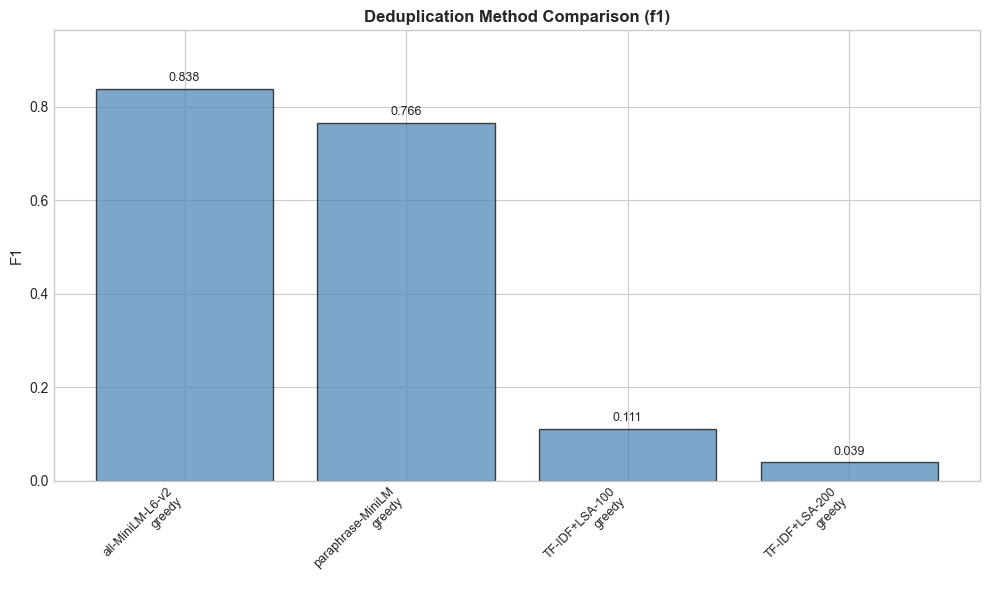

In [20]:
# Plot embedder comparison
if 'f1' in embedder_df.columns and embedder_df['f1'].notna().any():
    plot_method_comparison(
        embedder_results,
        metric='f1',
        figsize=(10, 6),
        save_path=IMAGES_DIR / 'dedup_embedder_comparison.png'
    )
else:
    print("Skipping F1 comparison plot (no labeled pairs)")

## 6. Dimensionality Reduction

Visualize the embedding space to understand cluster structure.

Creating UMAP visualization...
Install with: pip install umap-learn


Figure saved to /home/fdpearce/Documents/Courses/DataTalksClub/projects/machine-learning-zoomcamp/sportswear-esg-news-classifier/images/dedup_embedding_space_umap.png


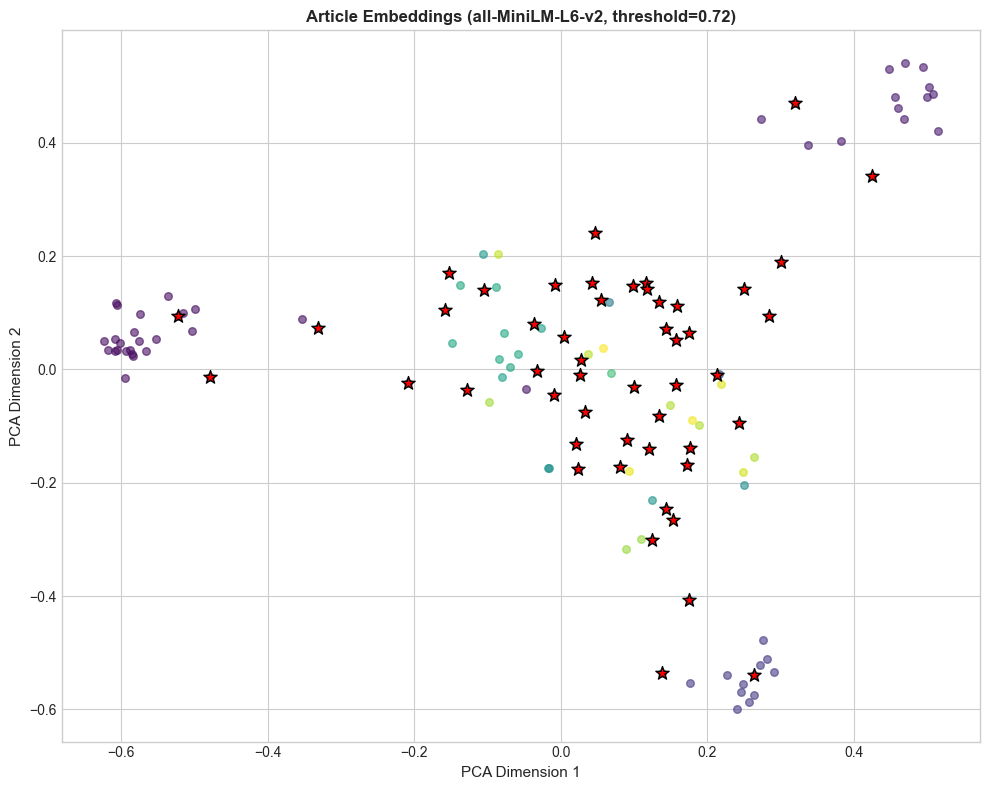

In [21]:
# Visualize baseline embeddings with UMAP
print("Creating UMAP visualization...")
plot_embedding_space(
    baseline_embeddings,
    baseline_meta['cluster_labels'],
    method='umap',
    figsize=(10, 8),
    highlight_indices=baseline_keep[:50],  # Highlight first 50 representatives
    save_path=IMAGES_DIR / 'dedup_embedding_space_umap.png',
    title=f'Article Embeddings (all-MiniLM-L6-v2, threshold={CURRENT_THRESHOLD})'
)


Creating PCA visualization...


Figure saved to /home/fdpearce/Documents/Courses/DataTalksClub/projects/machine-learning-zoomcamp/sportswear-esg-news-classifier/images/dedup_embedding_space_pca.png


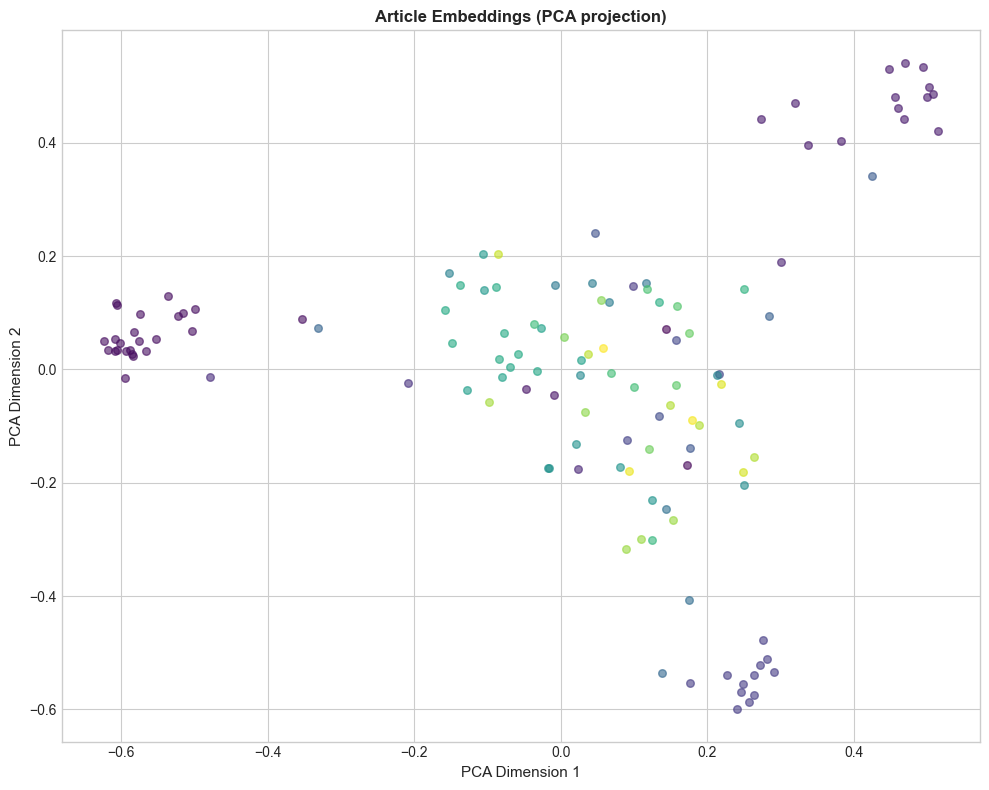

In [22]:
# Visualize with PCA (faster, linear baseline)
print("\nCreating PCA visualization...")
plot_embedding_space(
    baseline_embeddings,
    baseline_meta['cluster_labels'],
    method='pca',
    figsize=(10, 8),
    save_path=IMAGES_DIR / 'dedup_embedding_space_pca.png',
    title=f'Article Embeddings (PCA projection)'
)

### 6.1 Dimensionality Reduction as Preprocessing

Test whether reducing embedding dimensionality (384 → 50-100 dims) before clustering improves deduplication quality.

In [23]:
# Test dimensionality reduction as preprocessing before clustering
# NOTE: Using TUNING set only for comparison
from sklearn.decomposition import PCA

dimred_results = []
dimred_configs = [
    {'name': 'baseline_384', 'n_components': None},  # No reduction
    {'name': 'pca_100', 'n_components': 100},
    {'name': 'pca_50', 'n_components': 50},
]

print("Testing dimensionality reduction as preprocessing...")
print("(Evaluated on TUNING set only)")
print("=" * 70)

for config in dimred_configs:
    name = config['name']
    n_components = config['n_components']
    
    # Apply dimensionality reduction
    if n_components is None:
        reduced_embeddings = baseline_embeddings
        actual_dims = baseline_embeddings.shape[1]
    else:
        pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
        reduced_embeddings = pca.fit_transform(baseline_embeddings)
        actual_dims = n_components
        print(f"\n{name}: Reduced {baseline_embeddings.shape[1]} → {actual_dims} dims")
        print(f"  Explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")
    
    # Test greedy clustering at different thresholds
    for threshold in [0.68, 0.70, 0.72, 0.75, 0.80]:
        keep_indices, meta = greedy_cosine_clustering(reduced_embeddings, threshold=threshold)
        cluster_metrics = calculate_cluster_metrics(reduced_embeddings, meta['cluster_labels'])
        
        result = {
            'preprocessing': name,
            'dims': actual_dims,
            'threshold': threshold,
            'n_kept': len(keep_indices),
            'reduction_rate': meta['duplicates_removed'] / len(reduced_embeddings),
            'silhouette_score': cluster_metrics['silhouette_score'],
        }
        
        # Evaluate on TUNING pairs
        if tuning_pairs:
            article_ids = df['article_id'].astype(str).tolist()
            eval_result = evaluate_on_labeled_pairs(
                reduced_embeddings, article_ids, tuning_pairs, meta['cluster_labels']
            )
            result.update({
                'precision': eval_result['precision'],
                'recall': eval_result['recall'],
                'f1': eval_result['f1'],
            })
        
        dimred_results.append(result)

dimred_df = pd.DataFrame(dimred_results)
print("\n" + "=" * 70)
print("DIMENSIONALITY REDUCTION COMPARISON (TUNING SET)")
print("=" * 70)
print(dimred_df.to_string(index=False))

# Find best with recall constraint
if 'recall' in dimred_df.columns:
    optimal = find_optimal_threshold_with_recall_constraint(
        dimred_df.to_dict('records'),
        min_recall=MIN_RECALL_TARGET,
        recall_key='recall',
        precision_key='precision'
    )
    print(f"\n{'='*70}")
    print(f"OPTIMAL CONFIG (recall >= {MIN_RECALL_TARGET}):")
    if optimal['meets_recall_constraint']:
        cfg = optimal['config']
        print(f"  {cfg['preprocessing']} @ threshold={cfg['threshold']}")
        print(f"  Precision: {cfg['precision']:.3f}, Recall: {cfg['recall']:.3f}")
    else:
        print(f"  No config meets recall constraint. Best recall: {optimal['achieved_recall']:.3f}")

Testing dimensionality reduction as preprocessing...
(Evaluated on TUNING set only)

pca_100: Reduced 384 → 100 dims
  Explained variance ratio: 0.993



pca_50: Reduced 384 → 50 dims
  Explained variance ratio: 0.917

DIMENSIONALITY REDUCTION COMPARISON (TUNING SET)
preprocessing  dims  threshold  n_kept  reduction_rate  silhouette_score  precision  recall       f1
 baseline_384   384       0.68      54        0.578125          0.231635   0.790323    0.98 0.875000
 baseline_384   384       0.70      56        0.562500          0.219848   0.816667    0.98 0.890909
 baseline_384   384       0.72      59        0.539062          0.197558   0.800000    0.88 0.838095
 baseline_384   384       0.75      62        0.515625          0.186138   0.804878    0.66 0.725275
 baseline_384   384       0.80      72        0.437500          0.108041   0.771429    0.54 0.635294
      pca_100   100       0.68      71        0.445312          0.093643   0.733333    0.44 0.550000
      pca_100   100       0.70      74        0.421875          0.103666   0.695652    0.32 0.438356
      pca_100   100       0.72      75        0.414062          0.122417   0.

## 7. Clustering Algorithms

Compare different clustering algorithms beyond greedy cosine similarity.

In [24]:
# Define clustering methods to compare (including KMeans)
clustering_configs = {
    'greedy_0.75': {
        'method': 'greedy',
        'params': {'threshold': 0.75}
    },
    'greedy_0.80': {
        'method': 'greedy',
        'params': {'threshold': 0.80}
    },
    'hdbscan_2_1': {
        'method': 'hdbscan',
        'params': {'min_cluster_size': 2, 'min_samples': 1, 'metric': 'cosine'}
    },
    'hdbscan_3_2': {
        'method': 'hdbscan',
        'params': {'min_cluster_size': 3, 'min_samples': 2, 'metric': 'cosine'}
    },
    'agglom_0.25': {
        'method': 'agglomerative',
        'params': {'distance_threshold': 0.25, 'linkage': 'average', 'metric': 'cosine'}
    },
    'agglom_0.20': {
        'method': 'agglomerative',
        'params': {'distance_threshold': 0.20, 'linkage': 'average', 'metric': 'cosine'}
    },
    'kmeans_60': {
        'method': 'kmeans',
        'params': {'n_clusters': 60}  # ~50% reduction
    },
    'kmeans_80': {
        'method': 'kmeans',
        'params': {'n_clusters': 80}  # ~40% reduction
    },
}

print("Clustering methods to compare:")
for name, config in clustering_configs.items():
    print(f"  - {name}: {config['method']} with {config['params']}")

Clustering methods to compare:
  - greedy_0.75: greedy with {'threshold': 0.75}
  - greedy_0.80: greedy with {'threshold': 0.8}
  - hdbscan_2_1: hdbscan with {'min_cluster_size': 2, 'min_samples': 1, 'metric': 'cosine'}
  - hdbscan_3_2: hdbscan with {'min_cluster_size': 3, 'min_samples': 2, 'metric': 'cosine'}
  - agglom_0.25: agglomerative with {'distance_threshold': 0.25, 'linkage': 'average', 'metric': 'cosine'}
  - agglom_0.20: agglomerative with {'distance_threshold': 0.2, 'linkage': 'average', 'metric': 'cosine'}
  - kmeans_60: kmeans with {'n_clusters': 60}
  - kmeans_80: kmeans with {'n_clusters': 80}


In [25]:
# Compare clustering methods using baseline embeddings
# NOTE: Using TUNING set only for method selection
clustering_results = []

for name, config in clustering_configs.items():
    print(f"\nRunning {name}...")
    
    clustering_func = get_clustering_method(config['method'])
    keep_indices, meta = clustering_func(baseline_embeddings, **config['params'])
    cluster_metrics = calculate_cluster_metrics(baseline_embeddings, meta['cluster_labels'])
    
    result = {
        'name': name,
        'method': config['method'],
        'embedder': 'all-MiniLM-L6-v2',
        'n_kept': len(keep_indices),
        'n_removed': meta['duplicates_removed'],
        'reduction_rate': meta['duplicates_removed'] / len(baseline_embeddings),
        'n_clusters': meta['n_clusters'],
        'silhouette_score': cluster_metrics['silhouette_score'],
    }
    
    # Evaluate on TUNING pairs only
    if tuning_pairs:
        article_ids = df['article_id'].astype(str).tolist()
        eval_result = evaluate_on_labeled_pairs(
            baseline_embeddings, article_ids, tuning_pairs, meta['cluster_labels']
        )
        result.update({
            'precision': eval_result['precision'],
            'recall': eval_result['recall'],
            'f1': eval_result['f1'],
        })
    
    clustering_results.append(result)

clustering_df = pd.DataFrame(clustering_results)
print("\n" + "=" * 80)
print("CLUSTERING METHOD COMPARISON (TUNING SET)")
print("=" * 80)
print(clustering_df.to_string(index=False))

# Find optimal with recall constraint
if 'recall' in clustering_df.columns:
    optimal_clustering = find_optimal_threshold_with_recall_constraint(
        clustering_results,
        min_recall=MIN_RECALL_TARGET,
        recall_key='recall',
        precision_key='precision'
    )
    print(f"\n{'='*80}")
    print(f"OPTIMAL CLUSTERING METHOD (recall >= {MIN_RECALL_TARGET}):")
    if optimal_clustering['meets_recall_constraint']:
        cfg = optimal_clustering['config']
        print(f"  Method: {cfg['name']}")
        print(f"  Precision: {cfg['precision']:.3f}, Recall: {cfg['recall']:.3f}, F1: {cfg['f1']:.3f}")
    else:
        cfg = optimal_clustering['config']
        print(f"  No method meets recall constraint.")
        print(f"  Best recall: {cfg['name']} with recall={cfg['recall']:.3f}")


Running greedy_0.75...

Running greedy_0.80...

Running hdbscan_2_1...



Running hdbscan_3_2...

Running agglom_0.25...



Running agglom_0.20...

Running kmeans_60...



Running kmeans_80...



CLUSTERING METHOD COMPARISON (TUNING SET)
       name        method         embedder  n_kept  n_removed  reduction_rate  n_clusters  silhouette_score  precision  recall       f1
greedy_0.75        greedy all-MiniLM-L6-v2      62         66        0.515625          62          0.186138   0.804878    0.66 0.725275
greedy_0.80        greedy all-MiniLM-L6-v2      72         56        0.437500          72          0.108041   0.771429    0.54 0.635294
hdbscan_2_1       hdbscan all-MiniLM-L6-v2      67         61        0.476562          26          0.309078   0.947368    0.36 0.521739
hdbscan_3_2       hdbscan all-MiniLM-L6-v2      50         78        0.609375          10          0.355406   0.800000    0.96 0.872727
agglom_0.25 agglomerative all-MiniLM-L6-v2      62         66        0.515625          62          0.212999   0.826087    0.76 0.791667
agglom_0.20 agglomerative all-MiniLM-L6-v2      68         60        0.468750          68          0.196377   0.809524    0.68 0.739130
  kme

Figure saved to /home/fdpearce/Documents/Courses/DataTalksClub/projects/machine-learning-zoomcamp/sportswear-esg-news-classifier/images/dedup_clustering_comparison.png


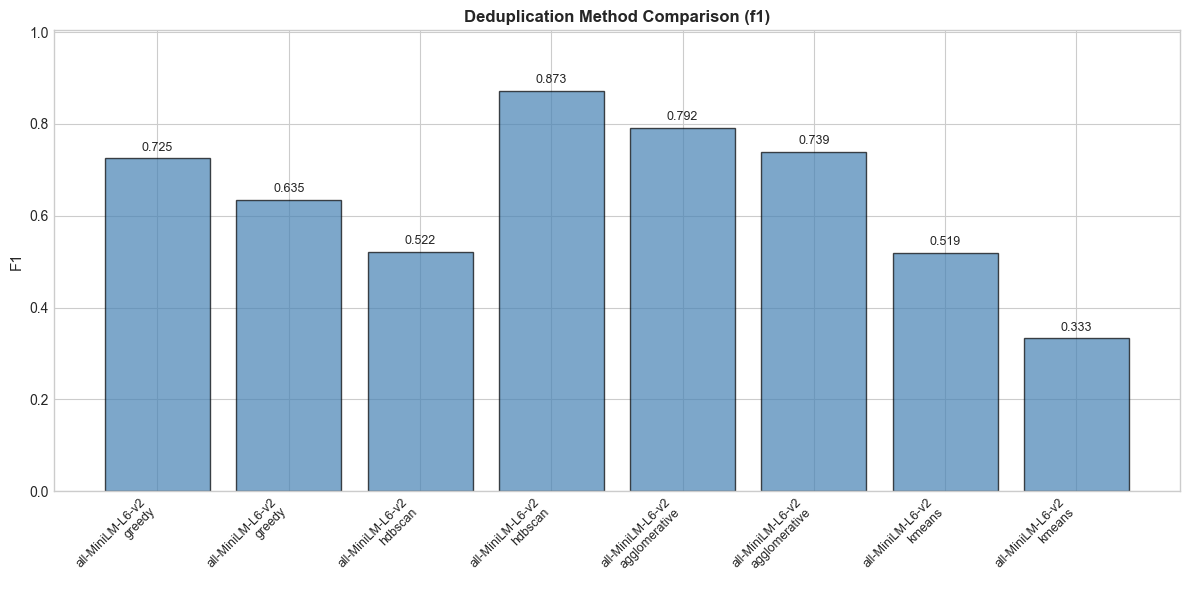

In [26]:
# Plot clustering comparison
if 'f1' in clustering_df.columns and clustering_df['f1'].notna().any():
    plot_method_comparison(
        clustering_results,
        metric='f1',
        figsize=(12, 6),
        save_path=IMAGES_DIR / 'dedup_clustering_comparison.png'
    )

## 8. Hyperparameter Tuning

Grid search over the best method's hyperparameters.

In [27]:
# Grid search for greedy method (most promising based on simplicity and performance)
# NOTE: Using TUNING set only for hyperparameter selection
greedy_grid = {
    'threshold': [0.65, 0.68, 0.70, 0.72, 0.74, 0.75, 0.76, 0.78, 0.80, 0.82, 0.85]
}

# Also test with different text lengths
text_lengths = [500, 1000, 1500, 2000]

tuning_results = []

for text_length in text_lengths:
    print(f"\nTesting text_length={text_length}...")
    
    # Prepare texts with different lengths
    test_texts = prepare_text_representations(
        df,
        max_content_chars=text_length,
        include_title=True
    )
    
    # Compute embeddings
    test_embeddings = baseline_embedder.transform(test_texts)
    
    for threshold in greedy_grid['threshold']:
        keep_indices, meta = greedy_cosine_clustering(test_embeddings, threshold=threshold)
        cluster_metrics = calculate_cluster_metrics(test_embeddings, meta['cluster_labels'])
        
        result = {
            'text_length': text_length,
            'threshold': threshold,
            'n_kept': len(keep_indices),
            'reduction_rate': meta['duplicates_removed'] / len(test_embeddings),
            'silhouette_score': cluster_metrics['silhouette_score'],
        }
        
        # Evaluate on TUNING set only
        if tuning_pairs:
            article_ids = df['article_id'].astype(str).tolist()
            eval_result = evaluate_on_labeled_pairs(
                test_embeddings, article_ids, tuning_pairs, meta['cluster_labels']
            )
            result.update({
                'precision': eval_result['precision'],
                'recall': eval_result['recall'],
                'f1': eval_result['f1'],
            })
        
        tuning_results.append(result)

tuning_df = pd.DataFrame(tuning_results)
print("\nTuning results (evaluated on TUNING set):")
print(tuning_df.to_string(index=False))


Testing text_length=500...



Testing text_length=1000...



Testing text_length=1500...



Testing text_length=2000...



Tuning results (evaluated on TUNING set):
 text_length  threshold  n_kept  reduction_rate  silhouette_score  precision  recall       f1
         500       0.65      54        0.578125          0.211893   0.818182    0.90 0.857143
         500       0.68      56        0.562500          0.185453   0.811321    0.86 0.834951
         500       0.70      57        0.554688          0.208266   0.846154    0.88 0.862745
         500       0.72      60        0.531250          0.222078   0.829787    0.78 0.804124
         500       0.74      61        0.523438          0.200139   0.840909    0.74 0.787234
         500       0.75      64        0.500000          0.183303   0.820513    0.64 0.719101
         500       0.76      65        0.492188          0.182438   0.793103    0.46 0.582278
         500       0.78      71        0.445312          0.121537   0.764706    0.26 0.388060
         500       0.80      77        0.398438          0.092788   0.882353    0.30 0.447761
         500     

In [28]:
# Find best configuration using RECALL-CONSTRAINED optimization
# Goal: Maximize precision while maintaining recall >= MIN_RECALL_TARGET

if 'recall' in tuning_df.columns and tuning_df['recall'].notna().any():
    optimal_tuning = find_optimal_threshold_with_recall_constraint(
        tuning_results,
        min_recall=MIN_RECALL_TARGET,
        recall_key='recall',
        precision_key='precision'
    )
    
    print("\n" + "=" * 60)
    print(f"BEST CONFIGURATION (recall >= {MIN_RECALL_TARGET})")
    print("=" * 60)
    
    if optimal_tuning['meets_recall_constraint']:
        best_config = optimal_tuning['config']
        print(f"\n✓ Found configuration meeting recall constraint!")
        print(f"\nText length: {best_config['text_length']}")
        print(f"Threshold: {best_config['threshold']}")
        print(f"Precision: {best_config['precision']:.4f}")
        print(f"Recall: {best_config['recall']:.4f} (target: >= {MIN_RECALL_TARGET})")
        print(f"F1 Score: {best_config['f1']:.4f}")
        print(f"Reduction rate: {best_config['reduction_rate']*100:.1f}%")
    else:
        best_config = optimal_tuning['config']
        print(f"\n✗ No configuration meets recall >= {MIN_RECALL_TARGET}")
        print(f"\nBest available (highest recall):")
        print(f"Text length: {best_config['text_length']}")
        print(f"Threshold: {best_config['threshold']}")
        print(f"Precision: {best_config['precision']:.4f}")
        print(f"Recall: {best_config['recall']:.4f}")
        print(f"\nConsider: Lower threshold or use HDBSCAN for higher recall")
    
    # Also show configs close to meeting constraint
    print("\n" + "-" * 60)
    print("Configs with highest recall (for reference):")
    high_recall = tuning_df.nlargest(5, 'recall')[['text_length', 'threshold', 'precision', 'recall', 'f1']]
    print(high_recall.to_string(index=False))
else:
    print("\nNo labeled pairs available for optimization.")
    print("Using silhouette score for selection...")
    
    valid_df = tuning_df[tuning_df['silhouette_score'].notna()]
    if len(valid_df) > 0:
        best_idx = valid_df['silhouette_score'].idxmax()
        best_config = tuning_df.loc[best_idx].to_dict()
        print(f"\nBest by silhouette: threshold={best_config['threshold']}, text_length={best_config['text_length']}")


BEST CONFIGURATION (recall >= 0.98)

✓ Found configuration meeting recall constraint!

Text length: 1000
Threshold: 0.7
Precision: 0.8167
Recall: 0.9800 (target: >= 0.98)
F1 Score: 0.8909
Reduction rate: 56.2%

------------------------------------------------------------
Configs with highest recall (for reference):
 text_length  threshold  precision  recall       f1
        1000       0.68   0.790323    0.98 0.875000
        1000       0.70   0.816667    0.98 0.890909
        1500       0.70   0.816667    0.98 0.890909
        2000       0.70   0.816667    0.98 0.890909
        1500       0.68   0.800000    0.96 0.872727


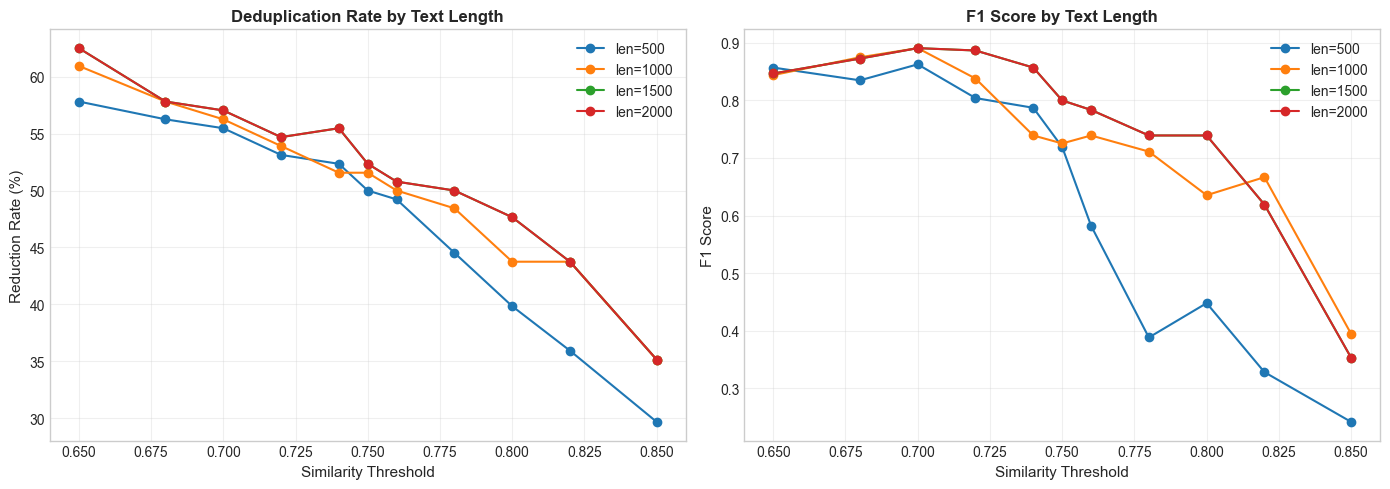

In [29]:
# Visualize tuning results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot threshold vs reduction rate by text length
ax1 = axes[0]
for text_length in text_lengths:
    subset = tuning_df[tuning_df['text_length'] == text_length]
    ax1.plot(subset['threshold'], subset['reduction_rate'] * 100, 'o-', label=f'len={text_length}')

ax1.set_xlabel('Similarity Threshold', fontsize=11)
ax1.set_ylabel('Reduction Rate (%)', fontsize=11)
ax1.set_title('Deduplication Rate by Text Length', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot threshold vs F1 (if available) or silhouette
ax2 = axes[1]
metric_col = 'f1' if 'f1' in tuning_df.columns and tuning_df['f1'].notna().any() else 'silhouette_score'
metric_label = 'F1 Score' if metric_col == 'f1' else 'Silhouette Score'

for text_length in text_lengths:
    subset = tuning_df[tuning_df['text_length'] == text_length]
    if subset[metric_col].notna().any():
        ax2.plot(subset['threshold'], subset[metric_col], 'o-', label=f'len={text_length}')

ax2.set_xlabel('Similarity Threshold', fontsize=11)
ax2.set_ylabel(metric_label, fontsize=11)
ax2.set_title(f'{metric_label} by Text Length', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'dedup_tuning_results.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.1 Final Evaluation on Holdout Set

Evaluate the selected configuration on the held-out test set for unbiased performance estimates.

In [30]:
# FINAL EVALUATION ON HOLDOUT SET
# This gives unbiased performance estimates

if holdout_pairs and 'best_config' in dir():
    print("=" * 60)
    print("FINAL EVALUATION ON HOLDOUT SET")
    print("=" * 60)
    print(f"\nHoldout set size: {len(holdout_pairs)} pairs")
    print(f"  - Duplicates: {sum(1 for p in holdout_pairs if p['is_duplicate'])}")
    print(f"  - Non-duplicates: {sum(1 for p in holdout_pairs if not p['is_duplicate'])}")
    
    # Prepare embeddings with best text length
    best_text_length = best_config.get('text_length', 1500)
    best_threshold = best_config.get('threshold', 0.72)
    
    final_texts = prepare_text_representations(
        df,
        max_content_chars=best_text_length,
        include_title=True
    )
    final_embeddings = baseline_embedder.transform(final_texts)
    
    # Run clustering with best config
    final_keep, final_meta = greedy_cosine_clustering(final_embeddings, threshold=best_threshold)
    
    # Evaluate on HOLDOUT set
    article_ids = df['article_id'].astype(str).tolist()
    holdout_eval = evaluate_on_labeled_pairs(
        final_embeddings, article_ids, holdout_pairs, final_meta['cluster_labels']
    )
    
    print(f"\nConfiguration tested:")
    print(f"  - Threshold: {best_threshold}")
    print(f"  - Text length: {best_text_length}")
    print(f"  - Algorithm: greedy cosine")
    
    print(f"\n{'='*60}")
    print("HOLDOUT SET RESULTS (UNBIASED ESTIMATES)")
    print("="*60)
    print(f"\nPrecision: {holdout_eval['precision']:.3f}")
    print(f"Recall:    {holdout_eval['recall']:.3f}")
    print(f"F1 Score:  {holdout_eval['f1']:.3f}")
    print(f"\nConfusion Matrix:")
    print(f"  TP: {holdout_eval['true_positives']}  FP: {holdout_eval['false_positives']}")
    print(f"  FN: {holdout_eval['false_negatives']}  TN: {holdout_eval['true_negatives']}")
    
    # Check if recall constraint is met on holdout
    if holdout_eval['recall'] >= MIN_RECALL_TARGET:
        print(f"\n✓ Recall constraint met on holdout: {holdout_eval['recall']:.3f} >= {MIN_RECALL_TARGET}")
    else:
        print(f"\n✗ Recall below target on holdout: {holdout_eval['recall']:.3f} < {MIN_RECALL_TARGET}")
        print("  Consider lowering threshold or collecting more validation data")
    
    # Store holdout results for recommendations
    holdout_results = holdout_eval.copy()
    holdout_results['threshold'] = best_threshold
    holdout_results['text_length'] = best_text_length
else:
    print("No holdout pairs available or no best config selected.")
    print("Run hyperparameter tuning first.")
    holdout_results = None

FINAL EVALUATION ON HOLDOUT SET

Holdout set size: 35 pairs
  - Duplicates: 21
  - Non-duplicates: 14



Configuration tested:
  - Threshold: 0.7
  - Text length: 1000
  - Algorithm: greedy cosine

HOLDOUT SET RESULTS (UNBIASED ESTIMATES)

Precision: 0.720
Recall:    0.857
F1 Score:  0.783

Confusion Matrix:
  TP: 18  FP: 7
  FN: 3  TN: 7

✗ Recall below target on holdout: 0.857 < 0.98
  Consider lowering threshold or collecting more validation data


## 9. Recommendations

Based on the analysis, determine the optimal deduplication configuration.

In [31]:
# Compile recommendations
print("\n" + "=" * 60)
print("DEDUPLICATION CONFIGURATION RECOMMENDATIONS")
print("=" * 60)

# Determine best embedding method
if 'f1' in embedder_df.columns and embedder_df['f1'].notna().any():
    best_embedder = embedder_df.loc[embedder_df['f1'].idxmax(), 'embedder']
else:
    best_embedder = 'all-MiniLM-L6-v2'  # Default to current production

# Determine best threshold
if 'f1' in tuning_df.columns and tuning_df['f1'].notna().any():
    best_threshold = tuning_df.loc[tuning_df['f1'].idxmax(), 'threshold']
    best_text_length = tuning_df.loc[tuning_df['f1'].idxmax(), 'text_length']
else:
    best_threshold = CURRENT_THRESHOLD
    best_text_length = 1000

print(f"\n1. EMBEDDING METHOD: {best_embedder}")
print(f"   - 384-dimensional, fast inference, good semantic quality")
print(f"   - Pre-trained on diverse text data")

print(f"\n2. SIMILARITY THRESHOLD: {best_threshold}")
if best_threshold != CURRENT_THRESHOLD:
    print(f"   - Changed from current production value ({CURRENT_THRESHOLD})")
else:
    print(f"   - Same as current production value")

print(f"\n3. TEXT LENGTH: {best_text_length} characters")
print(f"   - Title + first {best_text_length} chars of content")

print(f"\n4. ALGORITHM: Greedy cosine clustering")
print(f"   - Simple, deterministic, fast")
print(f"   - Performance comparable to more complex methods")


DEDUPLICATION CONFIGURATION RECOMMENDATIONS

1. EMBEDDING METHOD: all-MiniLM-L6-v2
   - 384-dimensional, fast inference, good semantic quality
   - Pre-trained on diverse text data

2. SIMILARITY THRESHOLD: 0.7
   - Changed from current production value (0.72)

3. TEXT LENGTH: 1000 characters
   - Title + first 1000 chars of content

4. ALGORITHM: Greedy cosine clustering
   - Simple, deterministic, fast
   - Performance comparable to more complex methods


In [32]:
# Save configuration to JSON
# Use holdout results for final metrics (unbiased)

if 'best_config' in dir():
    best_threshold = best_config.get('threshold', 0.72)
    best_text_length = best_config.get('text_length', 1500)
else:
    best_threshold = CURRENT_THRESHOLD
    best_text_length = 1500

dedup_config = {
    'embedding_model': best_embedder,
    'similarity_threshold': float(best_threshold),
    'text_max_length': int(best_text_length),
    'include_title': True,
    'algorithm': 'greedy_cosine',
    'analysis_date': datetime.now(timezone.utc).isoformat(),
    'optimization_target': f'max_precision_with_recall_>={MIN_RECALL_TARGET}',
    'metrics': {
        'articles_analyzed': len(df),
        'period_days': SCORECARD_PERIOD_DAYS,
    }
}

# Add tuning set metrics
if tuning_pairs and 'best_config' in dir():
    dedup_config['metrics']['tuning'] = {
        'n_pairs': len(tuning_pairs),
        'precision': float(best_config.get('precision', 0)),
        'recall': float(best_config.get('recall', 0)),
        'f1': float(best_config.get('f1', 0)),
    }

# Add holdout set metrics (unbiased)
if 'holdout_results' in dir() and holdout_results:
    dedup_config['metrics']['holdout'] = {
        'n_pairs': len(holdout_pairs),
        'precision': float(holdout_results.get('precision', 0)),
        'recall': float(holdout_results.get('recall', 0)),
        'f1': float(holdout_results.get('f1', 0)),
        'note': 'Unbiased estimate from held-out test set'
    }

config_path = MODELS_DIR / 'dedup_config.json'
with open(config_path, 'w') as f:
    json.dump(dedup_config, f, indent=2)

print(f"\nConfiguration saved to: {config_path}")
print("\nConfiguration:")
print(json.dumps(dedup_config, indent=2))


Configuration saved to: /home/fdpearce/Documents/Courses/DataTalksClub/projects/machine-learning-zoomcamp/sportswear-esg-news-classifier/models/dedup_config.json

Configuration:
{
  "embedding_model": "all-MiniLM-L6-v2",
  "similarity_threshold": 0.7,
  "text_max_length": 1000,
  "include_title": true,
  "algorithm": "greedy_cosine",
  "analysis_date": "2026-02-09T10:09:10.897210+00:00",
  "optimization_target": "max_precision_with_recall_>=0.98",
  "metrics": {
    "articles_analyzed": 128,
    "period_days": 30,
    "tuning": {
      "n_pairs": 85,
      "precision": 0.8166666666666667,
      "recall": 0.98,
      "f1": 0.890909090909091
    },
    "holdout": {
      "n_pairs": 35,
      "precision": 0.72,
      "recall": 0.8571428571428571,
      "f1": 0.782608695652174,
      "note": "Unbiased estimate from held-out test set"
    }
  }
}


In [33]:
# Save comparison results
comparison_results = {
    'embedder_comparison': embedder_results,
    'clustering_comparison': clustering_results,
    'tuning_results': tuning_results,
    'sweep_results': sweep_results,
}

comparison_path = MODELS_DIR / 'dedup_comparison.json'
with open(comparison_path, 'w') as f:
    json.dump(comparison_results, f, indent=2, default=lambda x: float(x) if isinstance(x, (np.floating, np.integer)) else str(x))

print(f"Comparison results saved to: {comparison_path}")

Comparison results saved to: /home/fdpearce/Documents/Courses/DataTalksClub/projects/machine-learning-zoomcamp/sportswear-esg-news-classifier/models/dedup_comparison.json


## 10. Summary

In [34]:
print("=" * 60)
print("NOTEBOOK SUMMARY")
print("=" * 60)

print(f"\nDataset: {len(df)} articles from last {SCORECARD_PERIOD_DAYS} days")
print(f"  - Sources: {df['source_name'].nunique()} unique")
print(f"  - Date range: {df['published_at'].min()} to {df['published_at'].max()}")

print(f"\nBaseline Performance (threshold={CURRENT_THRESHOLD}):")
print(f"  - Articles kept: {len(baseline_keep)} ({len(baseline_keep)/len(df)*100:.1f}%)")
print(f"  - Duplicates removed: {baseline_meta['duplicates_removed']}")
print(f"  - Clusters: {baseline_meta['n_clusters']}")

if labeled_pairs:
    print(f"\nLabeled Validation Set:")
    print(f"  - Total pairs: {len(validation_pairs)}")
    print(f"  - Labeled pairs: {len(labeled_pairs)}")

print(f"\nRecommended Configuration:")
print(f"  - Embedding: {best_embedder}")
print(f"  - Threshold: {best_threshold}")
print(f"  - Text length: {best_text_length} chars")
print(f"  - Algorithm: greedy cosine clustering")

print(f"\nArtifacts saved:")
print(f"  - {config_path}")
print(f"  - {comparison_path}")
print(f"  - {validation_pairs_path}")
print(f"  - images/dedup_*.png")

print(f"\nNext Steps:")
print(f"  1. If validation pairs not labeled, manually label {validation_pairs_path}")
print(f"  2. Re-run notebook after labeling for accurate F1 optimization")
print(f"  3. Update scripts/export_website_feed.py if config changes recommended")
print(f"  4. Run tests: uv run pytest tests/test_deduplication.py -v")

print("=" * 60)

NOTEBOOK SUMMARY

Dataset: 128 articles from last 30 days
  - Sources: 109 unique
  - Date range: 2026-01-09 06:45:00 to 2026-02-07 16:42:12

Baseline Performance (threshold=0.72):
  - Articles kept: 59 (46.1%)
  - Duplicates removed: 69
  - Clusters: 59

Labeled Validation Set:
  - Total pairs: 120
  - Labeled pairs: 120

Recommended Configuration:
  - Embedding: all-MiniLM-L6-v2
  - Threshold: 0.7
  - Text length: 1000 chars
  - Algorithm: greedy cosine clustering

Artifacts saved:
  - /home/fdpearce/Documents/Courses/DataTalksClub/projects/machine-learning-zoomcamp/sportswear-esg-news-classifier/models/dedup_config.json
  - /home/fdpearce/Documents/Courses/DataTalksClub/projects/machine-learning-zoomcamp/sportswear-esg-news-classifier/models/dedup_comparison.json
  - /home/fdpearce/Documents/Courses/DataTalksClub/projects/machine-learning-zoomcamp/sportswear-esg-news-classifier/data/dedup_validation_pairs.jsonl
  - images/dedup_*.png

Next Steps:
  1. If validation pairs not labeled